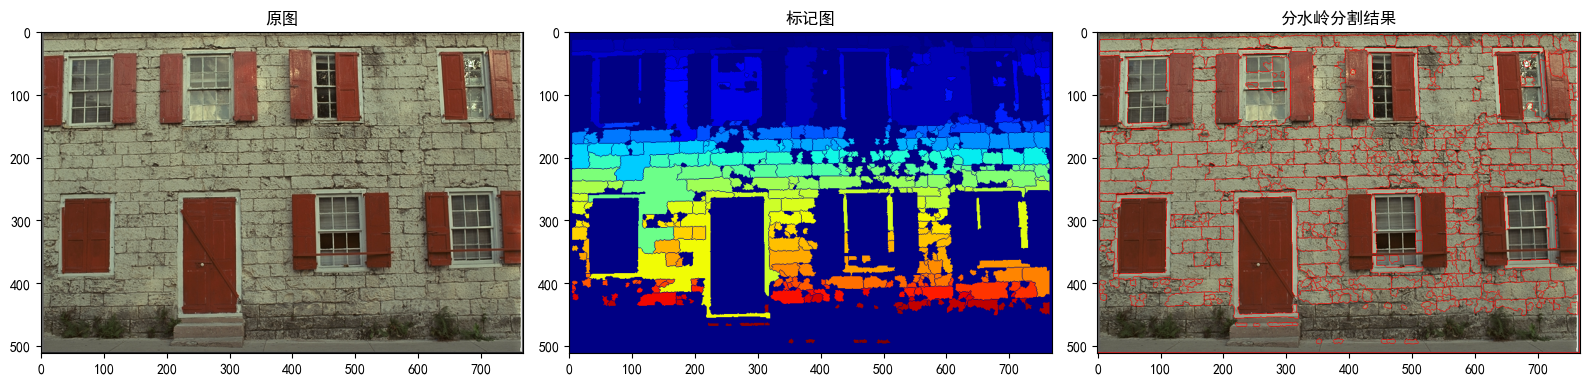

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 支持中文显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取图像（换成你的图片路径）
img = cv2.imread("kodim01.png")
img_copy = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------- 分水岭核心步骤 ---------------------
# 1. 二值化（Otsu自动阈值）
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. 形态学操作：去噪
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# 3. 确定背景
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 4. 距离变换 → 确定前景
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.1 * dist_transform.max(), 255, 0)

# 5. 制作标记
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)
markers += 1
markers[unknown == 255] = 0

# 6. 分水岭算法
markers = cv2.watershed(img_copy, markers)

# 7. 画出分割线（红色）
img_copy[markers == -1] = [0, 0, 255]

# --------------------- 显示结果 ---------------------
plt.figure(figsize=(16, 8))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("原图")

plt.subplot(132)
plt.imshow(markers, cmap="jet")
plt.title("标记图")

plt.subplot(133)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("分水岭分割结果")

plt.tight_layout()
plt.show()